<a href="https://colab.research.google.com/github/Joehersh1998/Hersh-690-HW-4/blob/main/Hershberger_Final_Project_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving minimum_wage_project_data.csv to minimum_wage_project_data.csv


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

In [ ]:
import pandas as pd

df = pd.read_csv(
    "minimum_wage_project_data.csv"
)

df.head(50)

,State,minimum_wage,poverty_rate,unemployment_rate
0,Alaska,13.000,10.5,4.8
1,Arkansas,11.000,16.3,4.2
2,Arizona,15.150,12.8,4.3
3,California,16.900,12.3,5.5
4,Colorado,15.160,9.7,3.8
5,Connecticut,16.940,10.1,4.2
6,Delaware,15.000,11.6,5.2
7,Florida,14.000,13.1,4.3
8,Hawaii,16.000,11.2,2.2
9,Iowa,7.250,11.1,3.5


In [ ]:
len(df)

50

**Descriptive Statistics**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   State              50 non-null     object 
 1   minimum_wage       50 non-null     float64
 2   poverty_rate       50 non-null     float64
 3   unemployment_rate  50 non-null     float64
dtypes: float64(3), object(1)
memory usage: 1.7+ KB


In [ ]:
df.describe()

,minimum_wage,poverty_rate,unemployment_rate
count,50.000000,50.000000,50.000000
mean,11.387660,12.540000,3.968000
std,3.807345,2.649682,0.800112
min,7.250000,7.200000,2.200000
25%,7.250000,10.800000,3.500000
50%,11.630000,12.100000,4.150000
75%,15.000000,13.825000,4.500000
max,17.130000,19.600000,5.500000


This table presents the descriptive statistics for the minimum wage, the poverty rate, and the unemployment rate variables across all fifty states. The average state minimum wage is approximately 11.39 per hour, with values ranging from the federal minimum wage of 7.25 per hour to a maximum of 17.13 per hour. The average poverty rate is 12.54 percent, while the average unemployment rate is 3.97 percent. The median values show that half of the states have a minimum wage below $11.63, a poverty rate below 12.1 percent, and unemployment rates below 4.15 percent.
One important difference between the two outcome variables is the amount of variation across the states. Poverty rates range from 7.2 percent to 19.6 percent and have a standard deviation of 2.65, indicating substantial variation among the states. In contrast, unemployment rates range from only 2.2 percent to 5.5 percent and have a standard deviation of .80, showing that unemployment rates are much more closely clustered around the average. Because unemployment rates exhibit less variation, it may be more difficult to identify a strong relationship between minimum wages and unemployment.


In [ ]:
lowest_states = df[
    df["minimum_wage"] == 7.25
]

lowest_states[
    [
        "State",
        "minimum_wage",
        "poverty_rate",
        "unemployment_rate"
    ]
].sort_values("poverty_rate", ascending=False)

,State,minimum_wage,poverty_rate,unemployment_rate
45,Louisiana,7.25,19.6,4.2
46,Mississippi,7.25,19.4,3.4
14,Kentucky,7.25,16.5,4.5
43,Alabama,7.25,16.1,2.7
31,Oklahoma,7.25,15.6,3.6
47,South Carolina,7.25,14.6,4.8
36,Texas,7.25,14.2,4.3
44,Georgia,7.25,14.0,3.6
48,Tennessee,7.25,13.6,3.6
22,North Carolina,7.25,13.4,3.9


This table displays the twenty states that have maintained the federal minimum wage of $7.25 per hour. Several of these states have some of the highest poverty rates in the country, with Louisiana and Mississippi approaching 20%. Furthermore, more than half of these states have poverty rates that are above the national average. At the same time, more than half of these states also have unemployment rates below the national average.

I also observed that states with higher poverty rates do not always experience higher unemployment rates. For example, Mississippi and Alabama have relatively high poverty rates while maintaining unemployment rates below the national average. This suggests that poverty and unemployment are not always closely related and may be affected by different economic factors.

Another thing to consider is that several of these states border states with higher minimum wages. For example, New Hampshire borders Massachusetts and Vermont, while Wisconsin borders Minnesota and Michigan. Labor markets and economic conditions specific to that region may also influence the poverty and unemployment outcomes of neighboring states.



In [ ]:
top10 = df.sort_values(
    "minimum_wage",
    ascending=False
).head(10)

top10[
    [
        "State",
        "minimum_wage",
        "poverty_rate",
        "unemployment_rate"
    ]
]

,State,minimum_wage,poverty_rate,unemployment_rate
40,Washington,17.13,9.9,4.7
29,New York,17.00,13.9,4.6
5,Connecticut,16.94,10.1,4.2
3,California,16.90,12.3,5.5
32,Oregon,16.30,12.2,5.2
8,Hawaii,16.00,11.2,2.2
34,Rhode Island,16.00,11.4,4.3
26,New Jersey,15.92,10.2,5.4
4,Colorado,15.16,9.7,3.8
2,Arizona,15.15,12.8,4.3


After looking at the states that kept their minimum wages at the federal level, I decided to look at the top ten states with the highest minimum wages. Six of the ten states have poverty rates below the national average. Of the remaining four states, Oregon is tied with the national average, while California and Arizona are only slightly below it. New York is the only one with a poverty rate that is more than one percentage point above the national average.

When examining the unemployment rates, eight of the ten states have unemployment rates above the national average. However, five of those eight states exceed the average by less than one percentage point. These findings suggest that higher minimum wage states generally have lower poverty rates, while the difference in the unemployment rate is minor.




In [ ]:
average_wage = df[
    df["minimum_wage"] > 7.25
]["minimum_wage"].mean()

df["wage_group"] = "Federal ($7.25)"

df.loc[
    (df["minimum_wage"] > 7.25) &
    (df["minimum_wage"] < average_wage),
    "wage_group"
] = "Below Average"

df.loc[
    df["minimum_wage"] >= average_wage,
    "wage_group"
] = "Above Average"

In [ ]:
group_summary = (
    df.groupby("wage_group")[
        ["poverty_rate", "unemployment_rate"]
    ]
    .mean()
    .round(2)
)

group_summary

,poverty_rate,unemployment_rate
wage_group,,
Above Average,11.30,4.21
Below Average,13.28,4.14
Federal ($7.25),13.21,3.65


To further examine the relationship between a state’s minimum wage, its poverty rate, and its unemployment rate, I divided the states into three groups. The first consisted of states with a minimum wage above the national average, which was approximately 14.25. The second group included states that had a minimum wage above the federal level but lower than the average of 14.25. The third group consisted of states that maintained the federal minimum wage of $7.25.

Because almost half of all states/observations maintained their minimum wage at the federal level, I excluded all but one when calculating the average minimum wage to create a more meaningful comparison. The results show that states with a minimum wage higher than the average had a poverty rate of 11.3%, which is lower than the national average. States that maintained the federal minimum wage and states below the national average both had poverty rates that are above 13%. Although both groups also have a slightly lower unemployment rate than states with an above-average minimum wage, the difference is relatively small. Overall, these findings suggest that higher minimum wages are associated with lower poverty rates, while the relationship between higher minimum wages and a state's unemployment rate remains unclear.


**Visulizations**

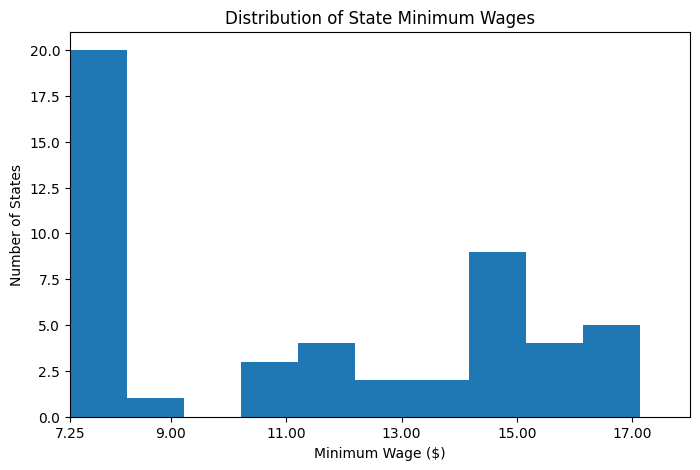

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df["minimum_wage"], bins=10)

plt.xlim(7.25, 18)

plt.xticks(
    [7.25, 9, 11, 13, 15, 17]
)

plt.xlabel("Minimum Wage ($)")
plt.ylabel("Number of States")
plt.title("Distribution of State Minimum Wages")

plt.show()

This histogram displays the distribution of state minimum wages in 2026. The graph shows that many states continue to maintain the federal minimum wage of 7.25 per hour, while a smaller group of states have a substantially higher minimum wage. Several states also have minimum wages above 15 dollars per hour, creating a second cluster at the higher end of the distribution. This uneven distribution demonstrates the large differences in minimum wage policies across the United States.

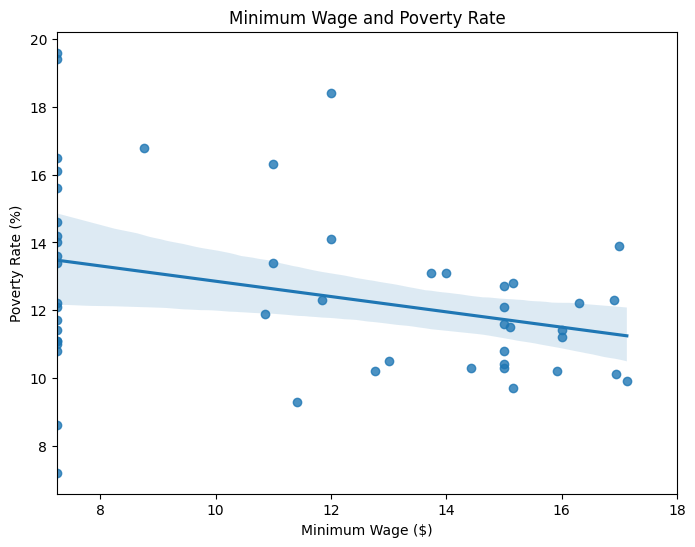

In [ ]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x="minimum_wage",
    y="poverty_rate"
)

plt.xlim(7.25, 18)

plt.xlabel("Minimum Wage ($)")
plt.ylabel("Poverty Rate (%)")
plt.title("Minimum Wage and Poverty Rate")

plt.show()

This scatter plot displays the relationship between state minimum wages and the state's poverty rate. The downward slope of the regression line indicates a negative relationship between the two variables, which means that states with a higher minimum wage tend to have lower levels of poverty.

States with a minimum wage near the federal minimum of $7.25 appear clustered toward the upper edge of the poverty rate,  while states with a higher minimum wage generally fall at lower poverty levels. Although individual states vary across the trend line, the overall pattern suggests that higher minimum wages may be linked to reduced poverty rates.



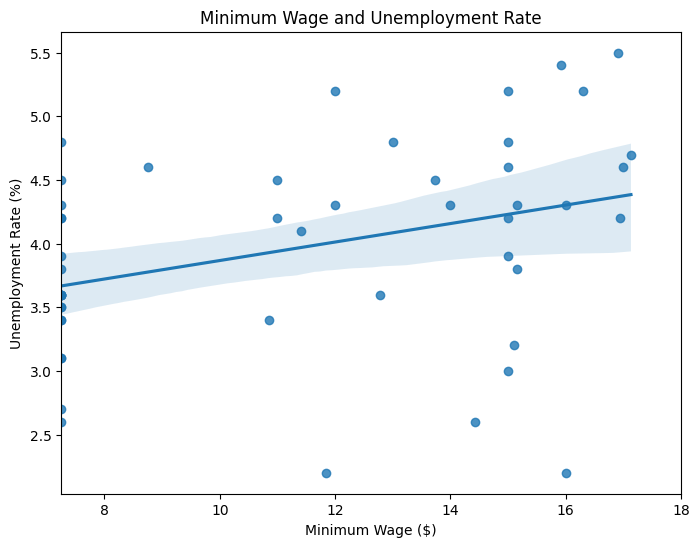

In [ ]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x="minimum_wage",
    y="unemployment_rate"
)

plt.xlim(7.25, 18)

plt.xlabel("Minimum Wage ($)")
plt.ylabel("Unemployment Rate (%)")
plt.title("Minimum Wage and Unemployment Rate")

plt.show()

This scatter plot illustrates the relationship between a state's minimum wage and its unemployment rate. The upward-sloping regression line suggests a slightly positive relationship, which means that states with higher minimum wages tend to have somewhat higher unemployment rates.  This relationship is weak, however, as states with similar minimum wages often display different unemployment levels. Overall, this plot provides limited evidence that higher minimum wages are associated with a meaningful increase in unemployment rates, indicating that other economic or structural factors such as the industries in that state and natural resources play a large role in shaping a states unemployment rate.


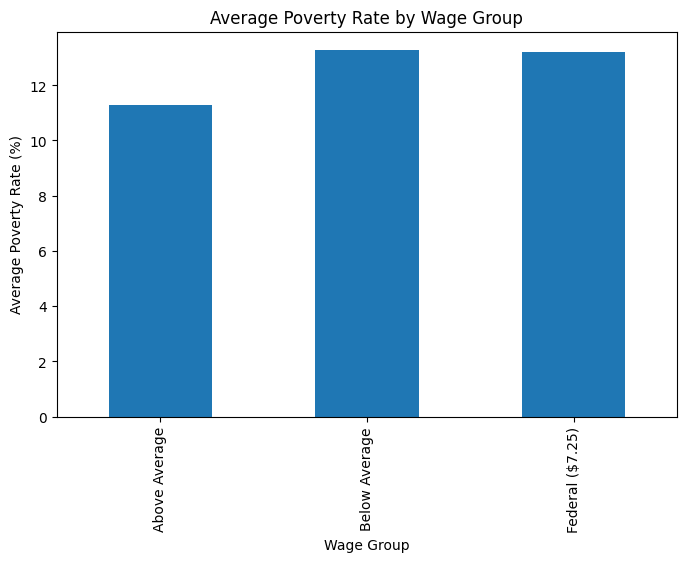

In [ ]:
group_summary["poverty_rate"].plot(
    kind="bar",
    figsize=(8,5)
)

plt.ylabel("Average Poverty Rate (%)")
plt.xlabel("Wage Group")
plt.title("Average Poverty Rate by Wage Group")

plt.show()

This graph displays the average poverty rates for the three minimum wage groups. States with an above-average minimum wage have the lowest average poverty rates. In contrast, states with below-average minimum wages and states that maintain the federal minimum wage both have average poverty rates of above 12 percent. Interestingly, the federal minimum wage states and the below-average wage states have nearly identical poverty rates, while the above-average wage states exhibit noticeably lower poverty rates. This suggests that states with substantially higher minimum wages may experience lower poverty rates than states with lower minimum wages. Overall, this figure provides additional evidence that higher minimum wages are associated with lower poverty rates.

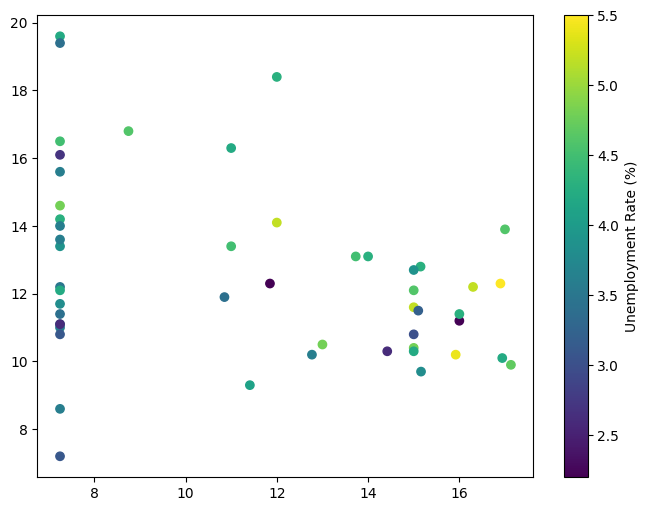

In [ ]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    df["minimum_wage"],
    df["poverty_rate"],
    c=df["unemployment_rate"]
)

plt.colorbar(scatter,
             label="Unemployment Rate (%)")

This visualization examines the relationship between the minimum wages, the poverty rates, and the unemployment rates across all fifty states. The horizontal position of each point represents the state's minimum wage, while the vertical position shows its poverty rate. The color of each point shows the unemployment rate, with darker colors representing lower unemployment and lighter colors showing higher unemployment. This figure suggests that states with higher minimum wages generally tend to have lower poverty rates, while unemployment rates vary across both low- and high-minimum-wage states.

States that had their minimum wage set at 7.25 are concentrated on the left side of the figure and often exhibit relatively higher poverty rates. In contrast, many states with minimum wages above 15 dollars per hour appear in the lower right portion of the graph, indicating lower poverty rates. The variation in colors suggests that unemployment rates do not follow a clear pattern with minimum wage levels, providing limited evidence that higher minimum wages substantially increase unemployment.


**Regression Analysis**

In [ ]:
import statsmodels.formula.api as smf

m1 = smf.ols(
    "poverty_rate ~ minimum_wage",
    data=df
).fit()

print(m1.summary())

                            OLS Regression Results                            
Dep. Variable:           poverty_rate   R-squared:                       0.105
Model:                            OLS   Adj. R-squared:                  0.087
Method:                 Least Squares   F-statistic:                     5.659
Date:                Tue, 30 Jun 2026   Prob (F-statistic):             0.0214
Time:                        23:27:18   Log-Likelihood:                -116.38
No. Observations:                  50   AIC:                             236.8
Df Residuals:                      48   BIC:                             240.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       15.1137      1.140     13.262   

These regression results indicate a negative relationship between the minimum wage and poverty rate. The coefficient for the minimum wage is -.226, which suggests that a one-dollar increase in a state minimum wage is associated with a decrease of approximately .23 percent in the poverty rate. The coefficient is also statistically significant, indicating the relationship is unlikely to be a result of something random. The model's R-squared value is .105, meaning that the minimum wage explains approximately 10.5% of the variation in the poverty rate across the states. This suggests that while minimum wage is a factor, there are also other policies besides minimum wage that contribute to the difference in the poverty rate per state. Overall, the results provide evidence that higher minimum wages are associated with lower poverty rates, although the effect is modest.


In [ ]:
m2 = smf.ols(
    "unemployment_rate ~ minimum_wage",
    data=df
).fit()

print(m2.summary())

                            OLS Regression Results                            
Dep. Variable:      unemployment_rate   R-squared:                       0.119
Model:                            OLS   Adj. R-squared:                  0.101
Method:                 Least Squares   F-statistic:                     6.514
Date:                Tue, 30 Jun 2026   Prob (F-statistic):             0.0139
Time:                        23:27:50   Log-Likelihood:                -56.110
No. Observations:                  50   AIC:                             116.2
Df Residuals:                      48   BIC:                             120.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        3.1408      0.341      9.199   

This result indicates that there is a positive relationship between the minimum wage and unemployment rates. The coefficient for minimum wage is .0726, which suggests that a one-dollar increase in a state's minimum wage is associated with an increase of about .007 percent in the unemployment rate. The coefficient is also statistically significant (p=.014). However, with that being said, the model's R-squared value is only .119. This means that the minimum wage only explains about 11.9 percent of the variation in the unemployment rate across the states.  This suggests that there are several other factors besides a state’s minimum wage that influence it's unemployment rate. Overall, while the results show that there is some evidence that a higher minimum wage is associated with a slightly higher unemployment rate, the effect is small.


**Conclusion**

The results of this research which was whether or not higher minimum wages are associated with lower poverty rates and higher unemployment rates are mixed. The descriptive statistics showed that  states that maintained a federal minumum wage of $7.25 generally experinced higher poverty rates than states that had a higher minimum wage. In contrast, unemployment rates varied much less across states and did not display the same clear pattern. The visulizations further demonstrated a negative relationship between higher minimum wages and poverty rates, while the relationship between a higher minimum wage and unemployment rates appeared much weaker.

My regression analysis further supported these findings. The poverty model found that higher minimum wages are associated with lower poverty rates, with a one-dollar increase in the minimum wage corresponding with a .23% decrease in the poverty rate. The unemployment model found that higher minimum wages are associated with slightly higher unemployment rates, although the effect was relatively small at approximately .07% for each one dollar increase in the minimum wage. Additionally, the low R-squared values in both models suggest that factors other than minimum wage policies also influence poverty and unemployment outcomes.

Overall, the results suggest that higher minimum wages are associated with lower poverty rates, while their relationship with unemployment is considerably weaker. Although higher minimum wages may be linked to modest increases in the unemployment rate, the reductions in the poverty rate appear to be more substantual. These findings show that minumum wage policies may improve the economic well-being for low income individuals while have a limited effect on unemployment rates.